# Combinatorial CoWork 2026 — Notebook 05: Noisy annulus and an `H^1` 2-persistence picture

Audience:
- Participants who want a point-cloud-side ingestion example that still lands on a mathematically interpretable degree-1 support picture.

Learning goals:
- Build a genuinely noisy annulus with interior points from the synthetic-data surface.
- Declare a `RipsCodensityFiltration` and inspect its resolved parameter contract.
- Reproduce a notebook-friendly codensity/radius snapshot panel for the raw cloud.
- Compute `stage=:cohomology_dims` in degree `1` and render the corresponding `H^1` support plane.


## Outline

1. Setup and build a noisy annulus with genuine interior noise
2. Inspect the point cloud and the codensity filtration contract
3. Compute pointwise codensity values for raw-cloud plotting
4. Draw a codensity/radius snapshot panel
5. Compute degree-1 cohomology dimensions and inspect the `H^1` support plane
6. Export the main figures


In [1]:
NOTEBOOK_STEM = "05_noisy_annulus_rips_codensity_h1_2persistence"

_TO_ROOT = let
    dir = abspath(pwd())
    root = nothing
    while true
        if isfile(joinpath(dir, "Project.toml")) && isfile(joinpath(dir, "src", "TamerOp.jl"))
            root = dir
            break
        end
        parent = dirname(dir)
        parent == dir && error("Could not locate repo root containing Project.toml and src/TamerOp.jl from pwd()=$(pwd()).")
        dir = parent
    end
    root
end

import Pkg
Pkg.activate(_TO_ROOT; io=devnull)

if !isdefined(Main, :TamerOp)
    @eval Main using TamerOp
end

TO = Main.TamerOp
using CairoMakie
using Random
using Statistics

CM = TO.CoreModules
OPT = TO.Options
SD = TO.SyntheticData
outdir = joinpath(_TO_ROOT, "examples", "_outputs", "combinatorial_cowork_2026", NOTEBOOK_STEM)
mkpath(outdir)


┌ Warning: attempting to remove probably stale pidfile
│   path = /home/eriknovak/.julia/compiled/v1.12/TamerOp/cHgq6_sg3Ik.ji.pidfile
└ @ FileWatching.Pidfile /home/eriknovak/.julia/juliaup/julia-1.12.1+0.x64.linux.gnu/share/julia/stdlib/v1.12/FileWatching/src/pidfile.jl:247

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught 

"/home/eriknovak/Documents/duke_fall_2025/tamer-op/examples/_outputs/combinatorial_cowork_2026/05_noisy_annulus_rips_codensity_h1_2persistence"

## 1. Build a noisy annulus with actual interior noise

`noisy_annulus(...)` is the synthetic-data source object we want here. We choose enough diffuse noise points that the middle of the annulus is visibly contaminated, so the codensity axis has something real to separate.


In [2]:
rng = MersenneTwister(20260323)
cloud = SD.noisy_annulus(
    n_annulus=120,
    n_noise=30,
    r_inner=0.75,
    r_outer=1.05,
    rng=rng,
)

cloud


PointCloud
  npoints: 230
  ambient_dim: 2
  eltype: Float64

The first inspection step is still the generic UX surface. `describe(...)` tells us what object we built, and `available_visuals(...)` shows that the point cloud is immediately ready for notebook-side visualization.


In [3]:
cloud_description = TO.describe(cloud)
cloud_visuals = TO.available_visuals(cloud)

(; cloud_description, cloud_visuals)


(cloud_description = (kind = :point_cloud, npoints = 230, ambient_dim = 2, eltype = Float64), cloud_visuals = (:points_2d, :point_density, :knn_graph, :radius_graph))

## 2. Declare the Rips-codensity filtration

This notebook uses the codensity version of the two-parameter Rips story. The filtration parameters are the public contract we want participants to read before they ask for cohomology dimensions.


In [4]:
construction = TO.ConstructionOptions(
    ;
    sparsify=:knn,
    collapse=:none,
    budget=(max_simplices=120_000, max_edges=80_000, memory_budget_bytes=1_000_000_000),
)

filtration = TO.RipsCodensityFiltration(
    ;
    max_dim=1,
    knn=10,
    dtm_mass=0.12,
    nn_backend=:auto,
    construction=construction,
)

filtration_description = TO.describe(filtration)
filtration_params = TO.filtration_parameters(filtration)

(; filtration_description, filtration_params)


(filtration_description = (kind = :rips_codensity, filtration_type = :RipsCodensityFiltration, arity = 2, key_params = (max_dim = 1, knn = 10, nn_backend = :auto, nn_approx_candidates = 0, dtm_mass = 0.12), construction_mode = (sparsify = :knn, collapse = :none, output_stage = :encoding_result)), filtration_params = (max_dim = 1, knn = 10, nn_backend = :auto, nn_approx_candidates = 0, dtm_mass = 0.12, construction = (sparsify = :knn, collapse = :none, output_stage = :encoding_result, budget = (max_simplices = 120000, max_edges = 80000, memory_budget_bytes = 1000000000))))

## 3. Compute reusable point codensity values

The codensity values themselves are now a reusable library object rather than notebook-local scaffolding. `point_codensity(...)` gives us the pointwise DTM-style codensity values attached to this cloud and this `RipsCodensityFiltration`.


In [5]:
pcod = TO.point_codensity(cloud, filtration)
snapshot_radii = [0.07, 0.16, 0.30]

pcod_description = TO.describe(pcod)

(; pcod_description,
   dtm_mass=TO.codensity_mass(pcod),
   neighbor_count=TO.neighbor_count(pcod),
   available_visuals=TO.available_visuals(pcod))


(codensity_range = (0.19921869827051242, 0.571501668263858), radii = [0.03, 0.07, 0.1], codensity_levels = [0.2471612133463502, 0.2731731658176964, 0.30799074025367085])

The point cloud can now be plotted directly from the codensity result object. The visual kind stays the ordinary point-cloud one, but the colors come from the codensity values automatically.


In [6]:
cloud_spec = TO.Visualization.visual_spec(pcod; kind=:points_2d)

(; cloud_visual_summary=TO.Visualization.visual_summary(cloud_spec))


(available_visuals = (:points_2d, :point_density, :knn_graph, :radius_graph), cloud_visual_summary = (kind = :visualization_spec, visual_kind = :points_2d, title = "Point cloud preview", subtitle = "2D point-cloud view", nlayers = 1, npanels = 0, layer_types = (:PointLayer,), axes = (xlabel = "x1", ylabel = "x2", xlimits = (-1.17515055567357, 1.257586950513116), ylimits = (-1.2297826519759112, 1.2675072760022175), zlabel = "z", zlimits = nothing, aspect = :equal, xticks = nothing, yticks = nothing), metadata = (object = :point_cloud, projected_dims = (1, 2), ambient_dim = 2, npoints = 230, overlay_density = false, legend_position = :none, figure_size = (720, 520)), legend_visible = false, interaction = (hover = true, labels = false, clicks = false, widgets = (), notebook = :summary_card)))

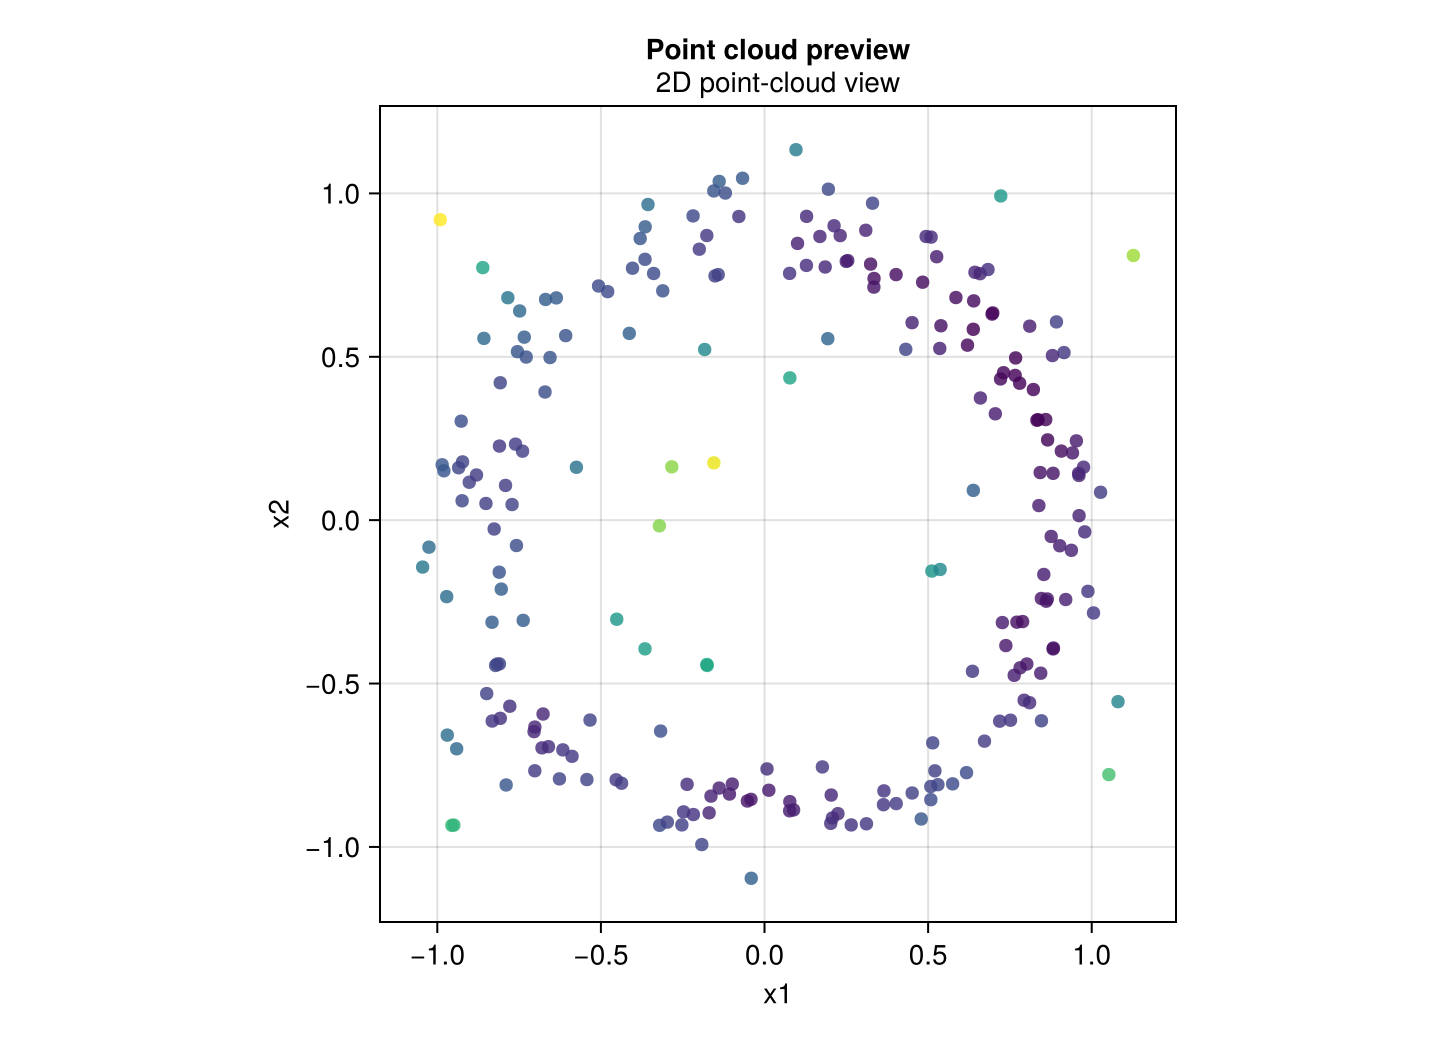

In [7]:
TO.visualize(pcod; kind=:points_2d, backend=:cairomakie)


## 4. Draw the codensity/radius snapshot panel

The multipers-style montage is now a reusable visualization kind on `PointCodensityResult`. We keep the same interpretation as before:
- rows filter by codensity cutoff,
- columns increase the proxy radius,
- point colors still record the codensity values.


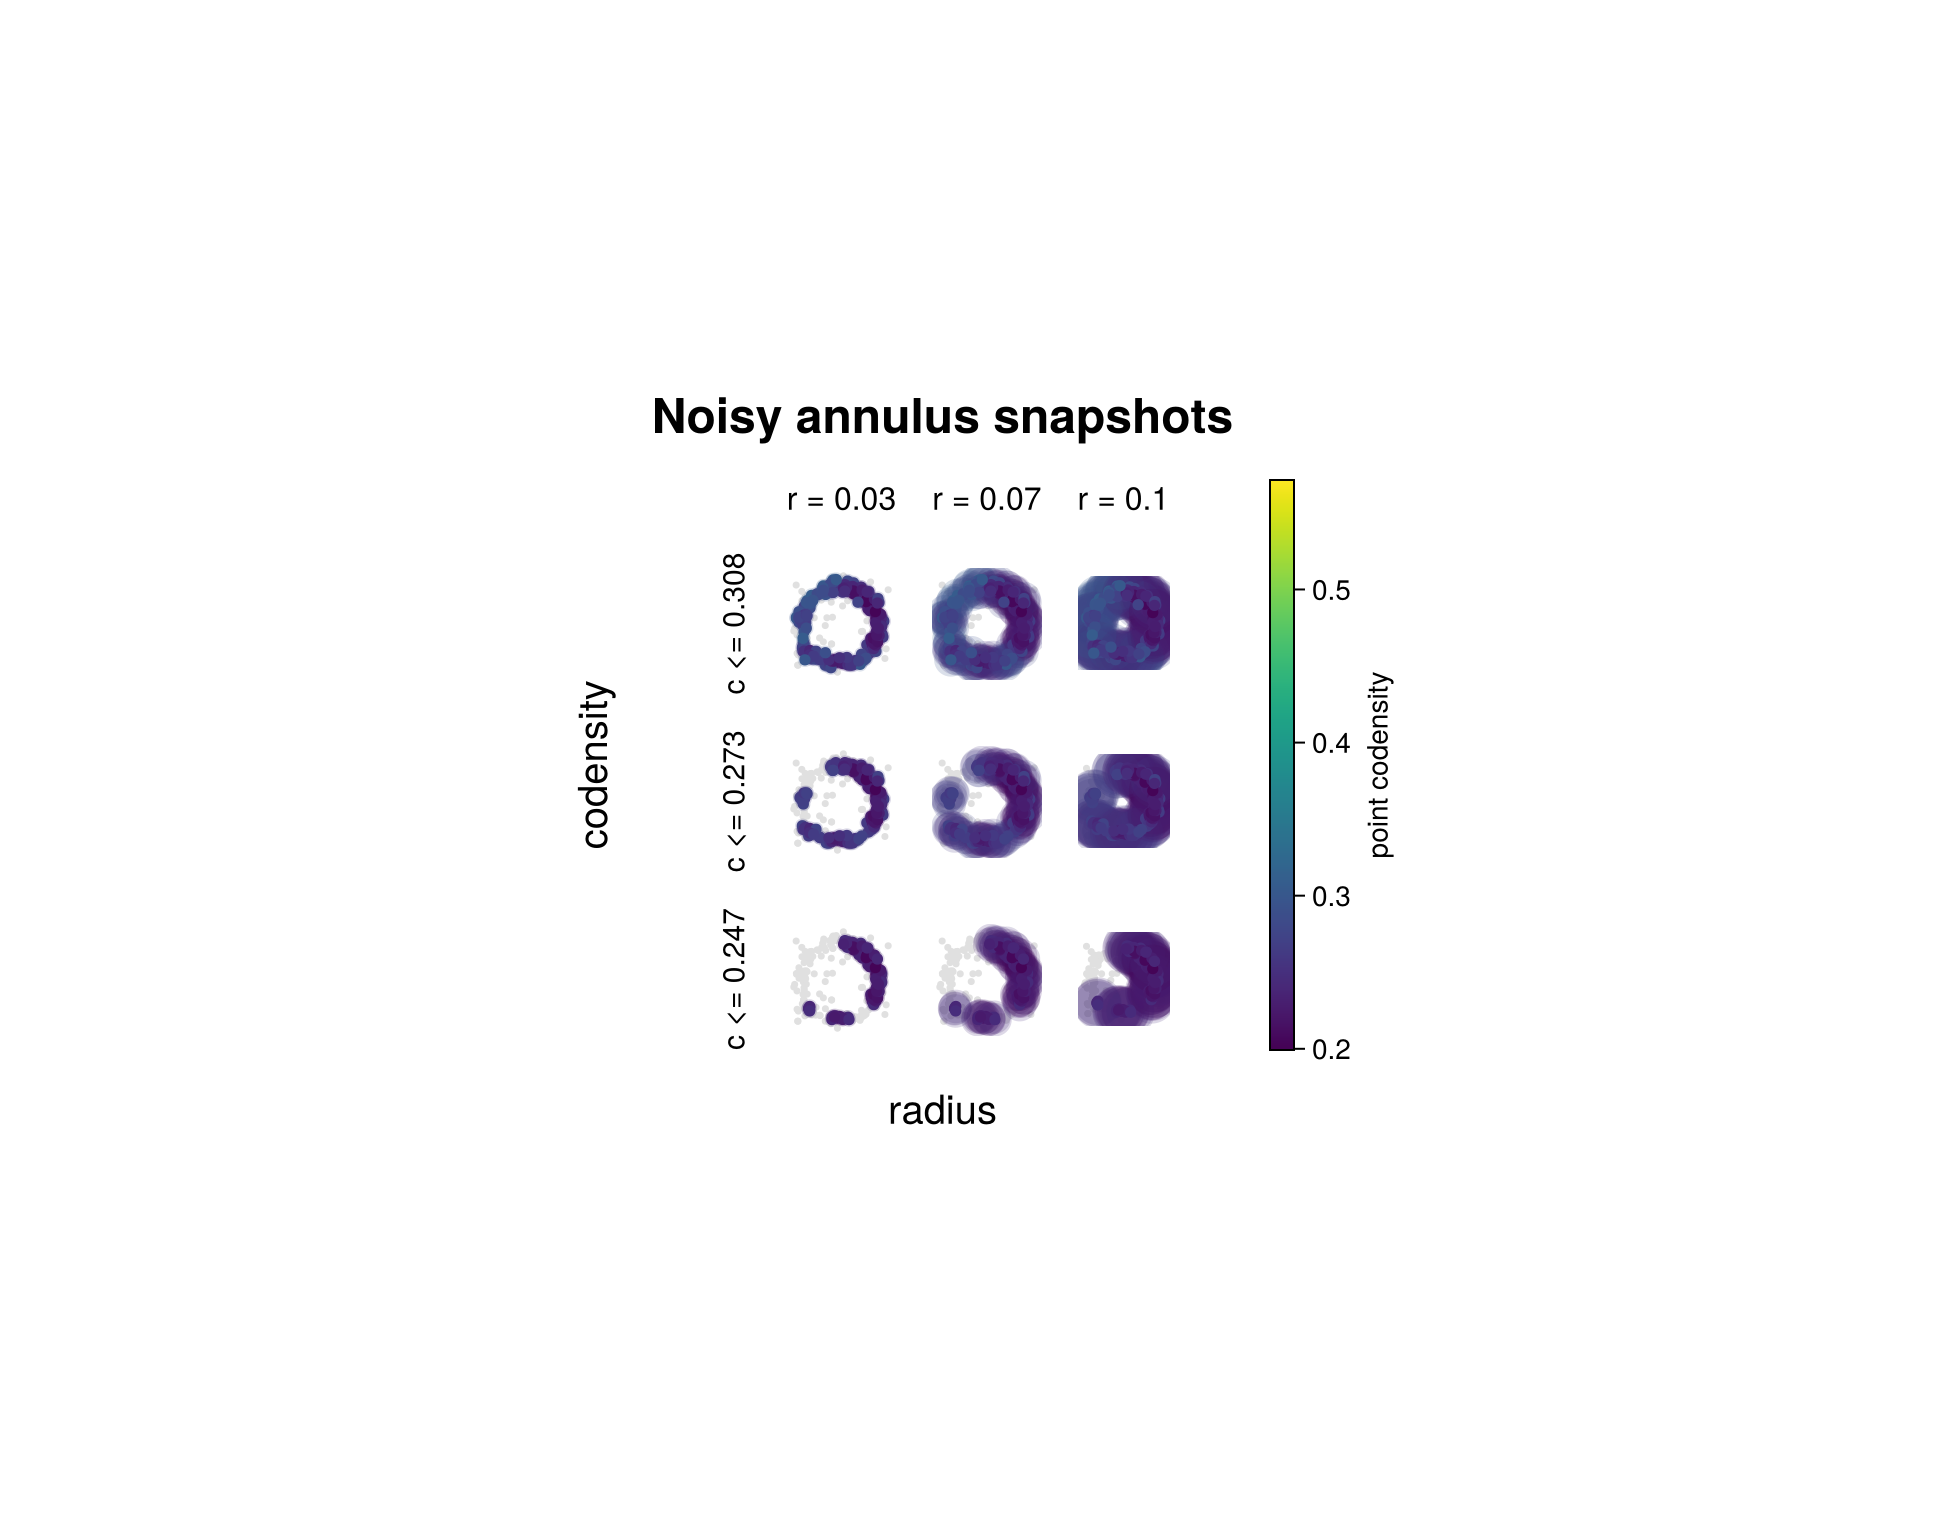

In [8]:
snapshot_spec = TO.Visualization.visual_spec(
    pcod;
    kind=:codensity_radius_snapshots,
    radii=snapshot_radii,
    codensity_levels=:quantiles,
)

(; snapshot_visual_summary=TO.Visualization.visual_summary(snapshot_spec))


In [ ]:
TO.visualize(pcod; kind=:codensity_radius_snapshots, radii=snapshot_radii, codensity_levels=:quantiles, backend=:cairomakie)


## 5. Compute degree-1 cohomology dimensions and inspect the `H^1` support plane

Now we leave the raw-cloud codensity object and return to the canonical cohomology-dims object. `stage=:cohomology_dims` gives a cheap degree-1 summary object, and `kind=:cohomology_support_plane` turns that into the notebook-facing 2-parameter support picture.

We use `F2()` here because this is a dims-only point-cloud demo; for this annulus, the degree-1 support story is the same, and `F2()` keeps the runtime modest.


In [9]:
h1_dims = TO.encode(
    cloud,
    filtration;
    degree=1,
    stage=:cohomology_dims,
    field=CM.F2(),
    cache=:auto,
)

h1_description = TO.describe(h1_dims)
h1_spec = TO.Visualization.visual_spec(h1_dims; kind=:cohomology_support_plane)

(; h1_description, h1_visual_summary=TO.Visualization.visual_summary(h1_spec), available_visuals=TO.available_visuals(h1_dims))


(h1_description = (kind = :cohomology_dims_result, poset_type = TamerOp.FiniteFringe.ProductOfChainsPoset{2}, dims_type = Vector{Int64}, dims_length = 324300, encoding_map_type = TamerOp.EncodingCore.CompiledEncoding{TamerOp.EncodingCore.GridEncodingMap{2, Float64, TamerOp.FiniteFringe.ProductOfChainsPoset{2}}, TamerOp.FiniteFringe.ProductOfChainsPoset{2}, Tuple{Vector{Float64}, Vector{Float64}}, Vector{Tuple{Float64, Float64}}, @NamedTuple{encoding_cache::TamerOp.CoreModules.EncodingCache}}, compiled = true, degree = 1, field_type = TamerOp.CoreModules.CoeffFields.PrimeField), h1_visual_summary = (kind = :visualization_spec, visual_kind = :cohomology_support_plane, title = "H^1 support plane", subtitle = "cohomology support on the bifiltration parameter plane", nlayers = 2, npanels = 0, layer_types = (:RectLayer, :RectLayer), axes = (xlabel = "x1", ylabel = "x2", xlimits = (-0.0015047980979294513, 0.5649429774597015), ylimits = (0.189741074883751, 0.5574441956733132), zlabel = "z", zl

In [ ]:
TO.visualize(h1_dims; kind=:cohomology_support_plane, backend=:cairomakie)

## 6. Export the main figures

All three visuals now live on the public library surface, so we export them uniformly through `save_visuals(...)`.


In [ ]:
exports = TO.save_visuals(outdir, [
    (; stem="annulus_codensity_points", obj=pcod, kind=:points_2d),
    (; stem="annulus_codensity_radius_snapshots", obj=pcod, kind=:codensity_radius_snapshots,
       radii=snapshot_radii, codensity_levels=:quantiles),
    (; stem="annulus_h1_support_plane", obj=h1_dims, kind=:cohomology_support_plane),
]; format=:png, backend=:cairomakie)

Dict(TO.export_stem(r) => TO.export_path(r) for r in exports)


## Try this next

- Increase `n_noise` and rerun only sections 1, 4, and 5. The codensity snapshot panel should fill in toward the center, and the `H^1` support plane should shrink.
- Increase `dtm_mass` and rerun sections 2, 3, 4, and 5. This makes the codensity statistic more global, so the snapshot rows become less permissive.
- Change the field in section 5 from `F2()` to `QQField()` if you want to verify that the degree-1 support picture is unchanged for this annulus.
